# Composite breakdown
Keep the original surface-PV segregation below. Then choose one sample, inspect one reconstruction, and average **all available selected eddy-days** at each exact fitted depth. Days receive equal weight; this is deliberately separate from the larger population workflow.

Each whole profile is translated to its 0 m fitted centre. No radius scaling, slope rotation, vertical interpolation or matched-depth filtering is added. Deeper levels may have fewer contributing days; the support table shows this. ESP fields are idealised reconstructions, without land/bathymetric masking in this simple notebook. Coordinates remain relative model-grid x/y; velocity components retain the external ESP function's convention.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
HERE = Path.cwd().resolve()
ANALYSIS = next((p for p in (HERE, *HERE.parents) if (p/'seacofs_tilt_tools.py').exists()), None)
if ANALYSIS is None:
    raise FileNotFoundError('Run from seacofs_eddy_tilt_analysis or a subdirectory')
WORK = ANALYSIS/'esp_population_composites'
for p in (ANALYSIS, WORK):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp
import seacofs_tilt_tools as tilt
pd.set_option('display.max_columns', 60)

# Reuse the dataset's directional-radius helper for the full composite refit.
DATASET_SRC = ANALYSIS.parent/'seacofs_eddy_dataset_modular'/'src'
if str(DATASET_SRC) not in sys.path:
    sys.path.insert(0, str(DATASET_SRC))
import composite_breakdown_tools as cbt


In [2]:
DOMINANCE_FACTOR = 2.0
ELLIPSE_FRAC = 1.0
MIN_PLAN_DEPTH_m = 3000.0
MAX_TOPO_DEPTH_m = 3000.0

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)

In [3]:
surface, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
surface = tilt.add_pv_gradient_terms(
    surface,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_cache=True, # change to true 
)
vertical = tilt.load_vert(paths)

In [4]:
surface['dom'] = 'mixed'
surface.loc[surface.topo_plan_ratio >=  np.log(DOMINANCE_FACTOR), 'dom'] = 'topo'
surface.loc[surface.topo_plan_ratio <= -np.log(DOMINANCE_FACTOR), 'dom'] = 'plan'

In [5]:
planetary = surface[(surface.dom=='plan')&(surface.h>=MIN_PLAN_DEPTH_m)].copy()
topographic = surface[(surface.dom=='topo')&(surface.h<=MAX_TOPO_DEPTH_m)].copy()

AE mean tilt dir 21, tilt dis 21 km
CE mean tilt dir 150, tilt dis 18 km


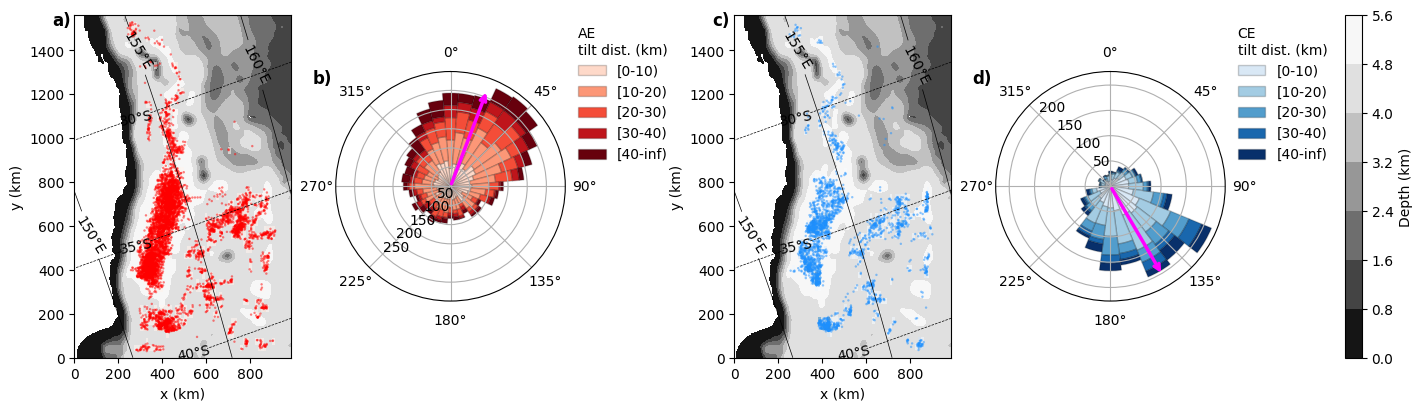

In [6]:
fig, axs = tilt.plot_tilt_summary(planetary.copy(), grid, mag_bins=[0, 10, 20, 30, 40, np.inf])

In [7]:
topographic

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region,h,f,beta,dhdx,dhdy,zeta_mean,...,PV_grad_eddy_coherence,PV_grad_full_x,PV_grad_full_y,PV_grad_full_mean_local_mag,PV_grad_full_rms_local_mag,PV_grad_full_p90_local_mag,PV_grad_full_coherence,PV_grad_plan_mag,PV_grad_plan_theta,PV_grad_topo_mag,PV_grad_topo_theta,PV_grad_mag,PV_grad_theta,PV_grad_eddy_mag,PV_grad_eddy_theta,PV_grad_full_mag,PV_grad_full_theta,dtheta_PV_grad,dtheta_PV_grad_topo,dtheta_PV_grad_plan,dtheta_PV_grad_full,Ro,topo_plan_ratio,topo_plan_ratio_smooth,ellipse_frac,ellipse_inner_frac,ellipse_area_fraction,pv_averaging,pv_surface_method,dom
118,4,1493,CE,150.518728,-37.464100,92,42,244.562541,208.329230,-0.000050,-0.000021,1.734126,-0.362949,0.657316,37.677021,14.865502,1.837577,22.337952,36,1994-02-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.652775,231.141407,S2,2859.392211,-0.000089,1.842881e-11,0.093953,-0.015892,-0.000040,...,0.469340,4.490278e-12,-1.083007e-12,4.648605e-12,8.328588e-12,1.425159e-11,0.993639,9.195990e-15,0.0,4.851263e-12,102.628493,4.849261e-12,102.522468,2.456622e-13,262.614571,4.619036e-12,103.560145,128.618939,128.512913,128.858593,127.581262,0.564797,6.268227,6.268227,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
119,4,1494,CE,150.430296,-37.456043,89,42,236.888864,206.512995,-0.000052,-0.000021,1.618557,-0.563463,0.878391,37.197425,13.298593,1.829614,22.925006,36,1994-02-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,7.981880,243.521114,S2,2079.860571,-0.000089,1.843033e-11,0.092980,-0.016552,-0.000041,...,0.627347,1.343765e-11,-3.668127e-12,1.401188e-11,2.284990e-11,4.452289e-11,0.994107,2.157437e-14,0.0,1.470887e-11,104.181178,1.470360e-11,104.099671,8.274811e-13,264.021250,1.392931e-11,105.268262,139.421443,139.339936,116.478886,138.252852,0.584148,6.524700,6.278428,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
120,4,1495,CE,150.354841,-37.452925,87,42,230.474313,204.573533,-0.000043,-0.000017,1.223692,-0.591723,1.274639,36.717828,11.731684,1.674290,21.223970,36,1994-02-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,S2,1498.939238,-0.000089,1.843128e-11,0.081873,-0.014957,-0.000035,...,0.603016,2.058836e-11,-5.789549e-12,2.155739e-11,3.030244e-11,5.779551e-11,0.992091,4.242998e-14,0.0,2.261307e-11,104.732420,2.260232e-11,104.628398,1.283872e-12,266.366850,2.138689e-11,105.706251,NaN,NaN,NaN,NaN,0.490398,6.278428,6.278428,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
121,4,1496,CE,150.324102,-37.358688,84,43,224.580419,213.431794,-0.000018,-0.000007,0.983503,-0.586885,1.471077,36.717828,11.731684,1.774191,18.715128,36,1994-02-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,S2,1282.549535,-0.000088,1.845422e-11,0.071745,-0.010367,-0.000014,...,0.538611,2.487503e-11,-5.639087e-12,2.572732e-11,3.588503e-11,6.168374e-11,0.991405,6.489363e-14,0.0,2.616343e-11,102.412953,2.614956e-11,102.274089,6.815114e-13,263.259440,2.550620e-11,102.772881,NaN,NaN,NaN,NaN,0.199662,5.999369,6.225974,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
122,4,1497,CE,150.404345,-37.335453,87,44,230.473201,218.252867,-0.000044,-0.000019,0.776010,-0.434028,1.564231,36.717828,11.731684,1.734425,19.287379,36,1994-02-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,S2,1745.194533,-0.000088,1.845861e-11,0.078084,-0.010573,-0.000035,...,0.576708,2.144715e-11,-4.357523e-12,2.210503e-11,3.343689e-11,6.311766e-11,0.990061,4.553672e-14,0.0,2.302863e-11,100.371933,2.302047e-11,100.260449,1.232295e-12,257.960130,2.188534e-11,101.484739,NaN,NaN,NaN,NaN,0.492633,6.225974,NaN,1.0,0.0,1.0,nonlinear,esp_gaussian,topo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127320,2979,10627,CE,160.329928,-29.820875,250,268,861.813328,1322.292405,-0.000012,-0.000005,1.115546,0.372644,1.022075,69.388241,12.9

## Choose the sample

In [8]:
# Change only this line to try another of your segregated samples.
sample = planetary.loc[planetary.Cyc.eq('CE')].copy()
REFERENCE_DEPTH_M = 0.0
MAX_COMPOSITE_DEPTH_M = None  # None uses every available fitted depth
print(f'Selected {len(sample)} eddy-days from {sample.Eddy.nunique()} eddies')


Selected 2250 eddy-days from 430 eddies


## Reconstruction helpers

In [ ]:
def valid_profiles(vertical):
    needed = ['Eddy', 'Day', 'Depth', 'xc', 'yc', 'Rc', 'Omega', 'q11', 'q12', 'q22']
    valid = vertical.loc[np.isfinite(vertical[needed].to_numpy(float)).all(axis=1)].copy()
    valid = valid.loc[(valid.Depth >= 0) & (valid.Rc > 0)
                      & (valid.q11 > 0) & (valid.q22 > 0)
                      & (valid.q11 * valid.q22 - valid.q12**2 > 0)]
    if valid.duplicated(['Eddy', 'Day', 'Depth']).any():
        raise ValueError('Duplicate Eddy-Day-Depth rows; resolve these before averaging.')
    return valid


def choose_case(surface, vertical, eddy_id=None, day=None, reference_depth=0.):
    # Match BOTH keys to the chosen sample, before choosing an example.
    keys = surface[['Eddy', 'Day']]
    if keys.duplicated().any():
        raise ValueError('Duplicate Eddy-Day rows in the selected sample.')
    valid = valid_profiles(vertical).merge(keys, on=['Eddy', 'Day'], validate='many_to_one')
    if eddy_id is not None:
        valid = valid.loc[valid.Eddy.eq(eddy_id)]
    if day is not None:
        valid = valid.loc[valid.Day.eq(day)]
    references = valid.loc[valid.Depth.eq(reference_depth), ['Eddy', 'Day']]
    if references.empty:
        raise ValueError('No selected eddy-day has a valid profile at the reference depth.')
    # Deterministic first available day (not the deepest or most tilted example).
    choice = references.sort_values(['Eddy', 'Day']).iloc[0]
    profile = valid.loc[valid.Eddy.eq(choice.Eddy) & valid.Day.eq(choice.Day)].sort_values('Depth').copy()
    row = surface.loc[surface.Eddy.eq(choice.Eddy) & surface.Day.eq(choice.Day)].iloc[0]
    return row, profile.reset_index(drop=True)


def recenter(profile, reference_depth=0.):
    profile = profile.copy()
    reference = profile.loc[profile.Depth.eq(reference_depth)]
    if len(reference) != 1:
        raise ValueError('Each day needs exactly one row at the common reference depth.')
    profile['xc'] -= float(reference.xc.iloc[0])
    profile['yc'] -= float(reference.yc.iloc[0])
    return profile


def reconstruct(profile, X, Y):
    # Input positions are kilometres; ESP expects metres.
    U, V = [], []
    for row in profile.itertuples(index=False):
        Q = np.array([[row.q11, row.q12], [row.q12, row.q22]])
        u, v = esp.model_uv_at_xy(X*1e3, Y*1e3, row.xc*1e3, row.yc*1e3,
                                  Q, row.Omega, row.Rc*1e3)
        U.append(u); V.append(v)
    if not U:
        raise ValueError('No fitted levels to reconstruct.')
    return np.stack(U, axis=-1), np.stack(V, axis=-1)


def composite_days(sample, vertical, X, Y, reference_depth=0., max_depth=None, return_centres=False):
    keys = sample[['Eddy', 'Day']].copy()
    if keys.duplicated().any():
        raise ValueError('Duplicate Eddy-Day rows in sample would double-count days.')
    valid = valid_profiles(vertical).merge(keys, on=['Eddy', 'Day'], validate='many_to_one')
    if max_depth is not None:
        valid = valid.loc[valid.Depth.le(max_depth)]
    ref_keys = valid.loc[valid.Depth.eq(reference_depth), ['Eddy', 'Day']]
    usable = valid.merge(ref_keys, on=['Eddy', 'Day'], validate='many_to_one')
    if usable.empty:
        raise ValueError('No selected days have a valid profile at the reference depth.')
    depths = np.sort(usable.Depth.unique())
    shape = (*X.shape, len(depths))  # y, x, exact fitted depth
    u_tot, v_tot = np.zeros(shape), np.zeros(shape)
    counts = np.zeros(shape, dtype=np.int64)
    depth_days = np.zeros(len(depths), dtype=np.int64)
    included = []
    centre_records = []
    for (eddy, day), profile in usable.groupby(['Eddy', 'Day'], sort=True):
        profile = recenter(profile.sort_values('Depth'), reference_depth)
        u, v = reconstruct(profile, X, Y)
        contributed = False
        for j, depth in enumerate(profile.Depth):
            k = np.searchsorted(depths, depth)
            finite = np.isfinite(u[..., j]) & np.isfinite(v[..., j])
            if not finite.any():
                continue
            u_tot[..., k] += np.where(finite, u[..., j], 0.)
            v_tot[..., k] += np.where(finite, v[..., j], 0.)
            counts[..., k] += finite
            depth_days[k] += 1
            # Record precisely the fitted levels that contributed finite velocity.
            centre_records.append(dict(Eddy=eddy, Day=day, Depth=float(depth),
                                       xc=float(profile.iloc[j].xc), yc=float(profile.iloc[j].yc)))
            contributed = True
        if contributed:
            included.append((eddy, day))
        if len(included) and len(included) % 100 == 0:
            print(f'Reconstructed {len(included)} eddy-days', flush=True)
    if not included:
        raise ValueError('ESP returned no finite velocity for the selected days.')
    u_ave = np.divide(u_tot, counts, out=np.full(shape, np.nan), where=counts > 0)
    v_ave = np.divide(v_tot, counts, out=np.full(shape, np.nan), where=counts > 0)
    included = pd.DataFrame(included, columns=['Eddy', 'Day'])
    audit = keys.merge(included.assign(included=True), on=['Eddy', 'Day'], how='left', validate='one_to_one')
    audit['included'] = audit.included.eq(True)
    ref_index = pd.MultiIndex.from_frame(ref_keys)
    has_reference = pd.MultiIndex.from_frame(audit[['Eddy', 'Day']]).isin(ref_index)
    audit['status'] = np.where(audit.included, 'included',
                             np.where(has_reference, 'no finite ESP velocity',
                                      'no valid profile at reference depth'))
    support = pd.DataFrame({'Depth': depths, 'eddy_days': depth_days,
                            'min_cell_days': counts.min(axis=(0, 1)),
                            'max_cell_days': counts.max(axis=(0, 1))})
    result = (u_ave, v_ave, depths, counts, support, audit)
    if return_centres:
        return (*result, pd.DataFrame(centre_records))
    return result


## Inspect one selected eddy-day

In [ ]:
WIDTH_KM = 400
RES_KM = 10
a = np.arange(-WIDTH_KM/2, WIDTH_KM/2 + RES_KM/2, RES_KM)
X, Y = np.meshgrid(a, a)

row, profile = choose_case(sample, vertical, reference_depth=REFERENCE_DEPTH_M)
profile = recenter(profile, REFERENCE_DEPTH_M)
u_esp, v_esp = reconstruct(profile, X, Y)
print(f'Example: Eddy {int(row.Eddy)}, Day {int(row.Day)}; {len(profile)} fitted levels')


In [ ]:
plt.contourf(X, Y, np.hypot(u_esp[:,:,0], v_esp[:,:,0]), cmap='magma')
plt.axis('equal')

## Composite all available selected eddy-days
A missing profile is skipped. Every exact depth has its own finite-value denominator; missing depths never contribute zero velocity.

In [ ]:
u_ave, v_ave, depths, counts, support, composite_audit, centre_members = composite_days(
    sample, vertical, X, Y, reference_depth=REFERENCE_DEPTH_M,
    max_depth=MAX_COMPOSITE_DEPTH_M, return_centres=True,
)
cnt = int(composite_audit.included.sum())
print(f'Included {cnt}/{len(sample)} selected eddy-days')
display(composite_audit.status.value_counts().rename('eddy_days'))
with pd.option_context('display.max_rows', None):
    display(support)


In [ ]:
# Plot at one actual fitted depth; no vertical interpolation.
PLOT_DEPTH_M = 500.0
k = int(np.argmin(np.abs(depths - PLOT_DEPTH_M)))
fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
im = axs[0].contourf(X, Y, np.hypot(u_ave[..., k], v_ave[..., k]), levels=20, cmap='magma')
fig.colorbar(im, ax=axs[0], label='Speed of mean ESP velocity (m/s)')
im = axs[1].pcolormesh(X, Y, counts[..., k], shading='auto')
fig.colorbar(im, ax=axs[1], label='Contributing eddy-days')
for ax in axs:
    ax.set(xlabel='Relative model-grid x (km)', ylabel='Relative model-grid y (km)', aspect='equal')
fig.suptitle(f'Composite at {depths[k]:.1f} m; {support.eddy_days.iloc[k]} eddy-days')
plt.show()

# y=0 section: v across x; x=0 section: u across y.
mid_y = int(np.argmin(abs(Y[:, 0])))
mid_x = int(np.argmin(abs(X[0, :])))

fig, axs = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
sections = [v_ave[mid_y, :, :].T, u_ave[:, mid_x, :].T]

for ax, section, coord, label, component in zip(
    axs, sections, [X[0, :], Y[:, 0]], ['x', 'y'], ['v', 'u']
):
    finite = section[np.isfinite(section)]
    limit = max(float(np.max(abs(finite))) if len(finite) else 0., 1e-12)

    im = ax.pcolormesh(coord, depths, section, shading='auto',
                       cmap='RdBu_r', vmin=-limit, vmax=limit)
    ax.contour(coord, depths, section, levels=[0], colors='k', linewidths=1.2)

    if len(depths) > 1:
        ax.set_ylim(depths[-1], depths[0])

    ax.set(xlabel=f'Relative model-grid {label} (km)', ylabel='Fitted depth (m)',
           title=f'Mean ESP {component} on central section')
    fig.colorbar(im, ax=ax, label='m/s')

plt.show()


## 1. Mean constituent centreline and uncertainty
`centre_members` contains the recentered fitted centre of **each contributing eddy-day at each depth**. `centre_stats` contains the equal-day mean, sample variance (`var_xc`, `var_yc`, km²), standard deviation (km), and x–y covariance (km²). The means use the same day weighting as the composite. When a reconstructed day is nonfinite at some grid cells, the field denominator remains cell-specific; the centre statistics include that day if it contributed anywhere at the depth.

**Variance/SD measure spread across the eddy-days, not uncertainty in the mean.** Separate 95% pointwise confidence intervals resample entire eddy IDs and retain all their days, while keeping the day-weighted estimator. They do not include errors in fitted positions or dependence between distinct neighbouring eddies. CI is undefined with only one eddy; sample variance is undefined with one day. At the common reference depth all recentered positions are zero by construction.

Coordinates describe shallow-to-deep displacement. `mean_tilt_x` and `mean_tilt_y` reverse that sign for deep-to-shallow displacement in model-grid axes; they are not a re-estimate of the existing whole-column `TiltDir`. Counts can decrease with depth, so the curve need not represent one unchanged population.

In [ ]:
CENTRE_BOOTSTRAPS = 500
CENTRE_SEED = 731
centre_stats = cbt.centre_statistics(centre_members, depths,
                                    n_boot=CENTRE_BOOTSTRAPS, seed=CENTRE_SEED)
# Verify that centre members exactly match the depth contributions counted above.
assert np.array_equal(centre_stats.n_eddy_days.to_numpy(), support.eddy_days.to_numpy())
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(centre_stats.round(6))
fig = cbt.plot_centrelines(centre_stats)
plt.show()


## 2. Fit the composite itself: DOPPIO inner core + ESP outer core
Fit the existing composite velocities, not averaged ESP parameters. At the first depth start the transects at `(0, 0)`; deeper levels use the last successful full fit's centre. Every exact depth is attempted. Numerical failures retain their reason and NaN reconstructed velocities; no fit is interpolated through a failure.

The fit uses `esp.doppio`, the dataset's `find_directional_radii`, and `esp.out_core_param_fit`. Transect coordinates and radii are kilometres, as in your modular fitting pipeline; velocities are m/s. Raw fitted rotation is divided by 1000 to store `w`, `Omega0`, and `Omega` in s⁻¹. `psi0` is converted to m²/s. Reconstructing the fitted field uses metres and SI `Omega`, exactly like the original daily reconstruction. `w` records the inner-core estimate; `w_full_fit = Omega*(q11+q22)` describes the complete fitted ESP field.

`fit_ok` means finite, geometrically valid inner/outer fits, not a guarantee of high skill. RMSE, normalised RMSE and vector R² are provided both inside the outer fitting region and over the supported grid. Low or negative R² is possible because a composite is not necessarily one ESP eddy. The 10 km grid may limit centre/radius precision: the default 30 km transect gives only seven points. You can later reduce `RES_KM` and rerun the reconstruction to check this.

Absolute fitted centres remain in the original recentered composite coordinates. `xc_from_fit_reference`/`yc_from_fit_reference` additionally subtract the first-depth fitted centre, if that fit succeeded. No further geographic or slope rotation is introduced.

In [ ]:
TRANSECT_RADIUS_KM = 30.0
RHO_MIN_KM = 30.0
RHO_MAX_KM = 200.0
OUT_CORE_FACTOR = 1.75
MAX_CENTRE_JUMP_KM = 100.0
MIN_FIT_CELL_DAYS = 1  # match the current available-day composite; support is reported
polarities = sample.Cyc.dropna().unique()
if len(polarities) != 1 or polarities[0] not in ('AE', 'CE'):
    raise ValueError('Select one polarity before fitting a composite eddy.')
EXPECTED_ROTATION_SIGN = 1 if polarities[0] == 'AE' else -1

composite_fit, u_fit, v_fit = cbt.fit_composite(
    X, Y, u_ave, v_ave, depths, counts, esp,
    transect_radius_km=TRANSECT_RADIUS_KM, rho_min_km=RHO_MIN_KM,
    rho_max_km=RHO_MAX_KM, out_core_fac=OUT_CORE_FACTOR,
    max_jump_km=MAX_CENTRE_JUMP_KM, min_cell_days=MIN_FIT_CELL_DAYS,
    expected_sign=EXPECTED_ROTATION_SIGN,
)
composite_fit = composite_fit.merge(
    centre_stats[['Depth', 'n_eddy_days', 'n_eddies']], on='Depth', validate='one_to_one'
)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(composite_fit)
print('Full inner/outer fits:', int(composite_fit.fit_ok.sum()), '/', len(composite_fit))
fig = cbt.plot_centrelines(centre_stats, composite_fit)
plt.show()


## Compare the fitted eddy with the original composite
The first two maps use the same speed colour scale. The error map measures the vector difference, not the difference of speeds. The 3-D view shows the fully fitted ESP velocities on up to six actual fitted depths, together with both centrelines. Gaps in the red centreline indicate failed full fits.

In [ ]:
FIT_PLOT_DEPTH_M = 500.0
k = int(np.argmin(abs(depths - FIT_PLOT_DEPTH_M)))
if composite_fit.fit_ok.iloc[k]:
    original_speed = np.hypot(u_ave[..., k], v_ave[..., k])
    fitted_speed = np.hypot(u_fit[..., k], v_fit[..., k])
    vector_error = np.hypot(u_fit[..., k]-u_ave[..., k], v_fit[..., k]-v_ave[..., k])
    vmax = float(np.nanmax([original_speed, fitted_speed]))
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for j, (ax, field, title) in enumerate(zip(axs, [original_speed, fitted_speed, vector_error],
                                             ['Original composite speed', 'Refitted ESP speed', 'Vector error'])):
        im = ax.pcolormesh(X, Y, field, shading='auto', cmap='magma', vmin=0,
                           vmax=vmax if j < 2 else None)
        ax.plot(centre_stats.mean_xc.iloc[k], centre_stats.mean_yc.iloc[k], 'co', label='Mean constituent centre')
        ax.plot(composite_fit.xc.iloc[k], composite_fit.yc.iloc[k], 'rx', label='Composite fit centre')
        ax.set(title=title, xlabel='Relative model-grid x (km)', ylabel='Relative model-grid y (km)', aspect='equal')
        fig.colorbar(im, ax=ax, label='m/s')
    axs[0].legend(fontsize=8)
    fig.suptitle(f'Composite and full ESP fit at {depths[k]:.1f} m')
    plt.show()
else:
    print(f'No full fit at {depths[k]:.1f} m:', composite_fit.reason.iloc[k])

fig = plt.figure(figsize=(9, 7), constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
ax.plot(centre_stats.mean_xc, centre_stats.mean_yc, depths, 'k.-', label='Mean constituent centre')
ax.plot(composite_fit.xc.where(composite_fit.fit_ok), composite_fit.yc.where(composite_fit.fit_ok),
        depths, 'r.--', label='Centre of full composite fit')
valid_levels = np.flatnonzero(composite_fit.fit_ok.to_numpy())
if len(valid_levels):
    shown = valid_levels[np.unique(np.linspace(0, len(valid_levels)-1, min(6, len(valid_levels))).astype(int))]
    step = max(1, len(a)//11)
    sl = (slice(None, None, step), slice(None, None, step))
    max_speed = np.nanmax(np.hypot(u_fit[..., shown], v_fit[..., shown]))
    arrow_scale = WIDTH_KM*0.08/max(max_speed, 1e-12)  # shared visual arrow scale, not distance travelled
    for k in shown:
        ok = np.isfinite(u_fit[..., k][sl]) & np.isfinite(v_fit[..., k][sl])
        ax.quiver(X[sl][ok], Y[sl][ok], np.full(ok.sum(), depths[k]),
                  u_fit[..., k][sl][ok]*arrow_scale, v_fit[..., k][sl][ok]*arrow_scale,
                  np.zeros(ok.sum()), color='tab:blue', alpha=.4)
ax.set(xlabel='Relative model-grid x (km)', ylabel='Relative model-grid y (km)', zlabel='Depth (m)',
       xlim=(a[0], a[-1]), ylim=(a[0], a[-1]), zlim=(depths[-1], depths[0]))
ax.legend()
plt.show()


The three dataframes remain available as `centre_members`, `centre_stats`, and `composite_fit`. The reconstructed full-fit arrays are `u_fit` and `v_fit`, with the same `[y, x, depth] layout as `u_ave`/`v_ave`. Optional export below writes only these centre/parameter tables.

In [ ]:
SAVE_CENTRE_TABLES = False
if SAVE_CENTRE_TABLES:
    SAVE_DIR = Path('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/composite_breakdown')
    SAVE_LABEL = 'planetary_CE'  # change this when changing sample; reruns overwrite these labelled files
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    centre_members.to_parquet(SAVE_DIR/f'{SAVE_LABEL}_centre_members.parquet', index=False)
    centre_stats.to_csv(SAVE_DIR/f'{SAVE_LABEL}_centre_stats.csv', index=False)
    composite_fit.to_csv(SAVE_DIR/f'{SAVE_LABEL}_composite_esp_fit.csv', index=False)
    print(SAVE_DIR)
